# Looking into ALL DESY3 $\lambda<20$ DESY3 redMaPPer objects on XMM observations

In [1]:
import daxa
daxa.NUM_CORES = 40
from daxa.mission import XMMPointed
from daxa.archive import Archive
from daxa.process.simple import full_process_xmm

from xga.sourcetools.misc import ang_to_rad

from astropy.units import Quantity
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import pandas as pd
import numpy as np

## Loading sample

Loading the DESY3 redMaPPer catalog:

In [2]:
with fits.open("../../../useful_samples/DES/redMaPPer/y3_gold_2.2.1_wide_sofcol_run2_redmapper_v6.4.22+2_lgt5_vl50_catalog.fit") as reado:
    rm_fits = Table(reado[1].data)
    nonvector_col_names = [name for name in rm_fits.colnames if len(rm_fits[name].shape) <= 1]
    desy3_samp = rm_fits[nonvector_col_names].to_pandas()

# Adding a name column with my standard naming scheme for RM clusters
desy3_samp.insert(1, 'name', desy3_samp['MEM_MATCH_ID'].apply(lambda x: 'DESY3RM-'+str(x)))

The whole sample:

In [3]:
desy3_samp

,MEM_MATCH_ID,name,RA,DEC,REFMAG,REFMAG_ERR,ZRED,ZRED_E,ZRED_CHISQ,BCG_SPEC_Z,...,Q_MISS,BCG_ILUM,ILUM,Z_LAMBDA_RAW,Z_LAMBDA_E_RAW,LIM_EXPTIME,LIM_LIMMAG_DERED,LIM_LIMMAG,LIM_LIMMAG_HARD,MASKGAL_INDEX
0,1,DESY3RM-1,43.564579,-58.952959,17.211803,0.003261,0.419903,0.019822,2.070493,-1.0,...,-5.499822,6.752811,154.952332,0.426756,0.002930,0.280946,22.476273,22.476273,23.559084,93
1,2,DESY3RM-2,83.231902,-37.026689,15.711882,0.001031,0.253236,0.010862,1.822323,-1.0,...,-16.255661,10.781266,160.152939,0.283757,0.002188,0.227620,22.317131,22.317131,23.559084,64
2,3,DESY3RM-3,347.092550,-2.192137,15.605037,0.001559,0.262504,0.011155,3.970640,-1.0,...,-26.678312,12.810082,133.820053,0.293272,0.002259,0.166704,22.081652,22.081652,23.559084,35
3,4,DESY3RM-4,79.155685,-54.500459,15.721151,0.001261,0.277025,0.011471,2.461007,-1.0,...,-15.530748,12.091534,146.935974,0.299716,0.001979,0.267186,22.438305,22.438305,23.559084,45
4,5,DESY3RM-5,343.585508,-46.346819,16.176292,0.001296,0.263685,0.011762,1.282380,-1.0,...,-13.001194,6.285003,118.404129,0.269913,0.002302,0.172497,22.107477,22.107477,23.559084,96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869330,1536086,DESY3RM-1536086,63.504022,-52.944847,20.980482,0.028716,0.859492,0.011270,30.344503,-1.0,...,0.374265,1.127470,3.155630,0.902700,0.028652,0.294289,22.511353,22.511353,23.559084,50
869331,1536094,DESY3RM-1536094,46.986519,-56.627891,21.288122,0.039129,0.883018,0.011829,35.491585,-1.0,...,0.252393,0.845667,2.872103,0.900775,0.017655,0.245196,22.373369,22.373369,23.559084,96
869332,1536096,DESY3RM-1536096,20.467247,-12.704754,20.587488,0.035502,0.925921,0.015058,8.753161,-1.0,...,-0.021522,1.693282,3.029833,0.923425,0.020353,0.236941,22.347477,22.347477,23.559084,40
869333,1536106,DESY3RM-1536106,82.645997,-22.024856,21.307264,0.038810,0.931214,0.013797,8.381010,-1.0,...,0.111873,0.890946,3.077770,0.932416,0.022564,0.279286,22.471790,22.471790,23.559084,98


## Cutting the sample down

### Richness

In [4]:
cut_samp = desy3_samp[desy3_samp['LAMBDA_CHISQ'] <= 20].reset_index(drop=True)
cut_samp

,MEM_MATCH_ID,name,RA,DEC,REFMAG,REFMAG_ERR,ZRED,ZRED_E,ZRED_CHISQ,BCG_SPEC_Z,...,Q_MISS,BCG_ILUM,ILUM,Z_LAMBDA_RAW,Z_LAMBDA_E_RAW,LIM_EXPTIME,LIM_LIMMAG_DERED,LIM_LIMMAG,LIM_LIMMAG_HARD,MASKGAL_INDEX
0,13,DESY3RM-13,342.179403,-44.528011,19.552191,0.020031,0.298372,0.017039,9.154387,-1.0,...,0.312723,0.491065,2.519670,0.345199,0.004135,0.234911,22.340971,22.340971,23.559084,86
1,22,DESY3RM-22,79.037258,-54.468903,18.824158,0.005987,0.335606,0.013674,7.190090,-1.0,...,0.310858,0.740317,4.067245,0.308671,0.003812,0.342603,22.626282,22.626282,23.559084,26
2,27,DESY3RM-27,323.831479,1.484002,17.643797,0.004119,0.212444,0.016494,15.878660,-1.0,...,0.188510,1.092355,3.670056,0.226225,0.003440,0.253904,22.399754,22.399754,23.559084,77
3,31,DESY3RM-31,71.758207,-37.104995,19.218773,0.011336,0.548985,0.017450,9.622556,-1.0,...,0.362922,1.979242,4.392631,0.565877,0.009137,0.233550,22.336576,22.336576,23.559084,14
4,33,DESY3RM-33,56.966810,-21.700130,18.232008,0.005726,0.387665,0.017122,8.350473,-1.0,...,-0.708699,1.791175,7.608072,0.357021,0.004539,0.218364,22.285746,22.285746,23.559084,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
815720,1536086,DESY3RM-1536086,63.504022,-52.944847,20.980482,0.028716,0.859492,0.011270,30.344503,-1.0,...,0.374265,1.127470,3.155630,0.902700,0.028652,0.294289,22.511353,22.511353,23.559084,50
815721,1536094,DESY3RM-1536094,46.986519,-56.627891,21.288122,0.039129,0.883018,0.011829,35.491585,-1.0,...,0.252393,0.845667,2.872103,0.900775,0.017655,0.245196,22.373369,22.373369,23.559084,96
815722,1536096,DESY3RM-1536096,20.467247,-12.704754,20.587488,0.035502,0.925921,0.015058,8.753161,-1.0,...,-0.021522,1.693282,3.029833,0.923425,0.020353,0.236941,22.347477,22.347477,23.559084,40
815723,1536106,DESY3RM-1536106,82.645997,-22.024856,21.307264,0.038810,0.931214,0.013797,8.381010,-1.0,...,0.111873,0.890946,3.077770,0.932416,0.022564,0.279286,22.471790,22.471790,23.559084,98


### Redshift

In [5]:
cut_samp = cut_samp[cut_samp['Z_LAMBDA'] < 0.3].reset_index(drop=True)
cut_samp

,MEM_MATCH_ID,name,RA,DEC,REFMAG,REFMAG_ERR,ZRED,ZRED_E,ZRED_CHISQ,BCG_SPEC_Z,...,Q_MISS,BCG_ILUM,ILUM,Z_LAMBDA_RAW,Z_LAMBDA_E_RAW,LIM_EXPTIME,LIM_LIMMAG_DERED,LIM_LIMMAG,LIM_LIMMAG_HARD,MASKGAL_INDEX
0,27,DESY3RM-27,323.831479,1.484002,17.643797,0.004119,0.212444,0.016494,15.878660,-1.000000,...,0.188510,1.092355,3.670056,0.226225,0.003440,0.253904,22.399754,22.399754,23.559084,77
1,124,DESY3RM-124,355.920050,0.312482,17.294031,0.003609,0.290798,0.012504,6.457511,0.271846,...,-1.587308,2.362426,6.515171,0.276145,0.004436,0.275629,22.461826,22.461826,23.559084,50
2,202,DESY3RM-202,349.857931,-1.273995,18.461910,0.003051,0.278766,0.017573,25.871456,-1.000000,...,0.157317,0.903789,5.440663,0.290620,0.004827,0.321926,22.579216,22.579216,23.559084,78
3,226,DESY3RM-226,358.833265,1.805540,17.484589,0.002086,0.201648,0.023750,19.973051,-1.000000,...,0.589382,1.254885,4.511350,0.225441,0.004062,0.200066,22.219578,22.219578,23.559084,84
4,300,DESY3RM-300,61.131523,-24.284729,18.099323,0.002863,0.298846,0.017454,33.998192,-1.000000,...,0.274714,1.030668,4.069881,0.265518,0.006313,0.451127,22.834332,22.834332,23.559084,66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38521,1443059,DESY3RM-1443059,14.934856,5.230267,18.485102,0.015787,0.301316,0.017626,3.272968,-1.000000,...,1.107803,0.895729,2.307304,0.292179,0.015484,0.084140,21.564705,21.564705,23.559084,57
38522,1444381,DESY3RM-1444381,5.227670,-27.207054,17.412973,0.002067,0.224136,0.009342,35.760941,-1.000000,...,1.203204,1.269782,2.804268,0.220029,0.009585,0.176143,22.123293,22.123293,23.559084,45
38523,1474037,DESY3RM-1474037,80.904523,-25.407234,17.178110,0.230884,0.317353,0.069172,36.351765,-1.000000,...,0.559586,1.329108,3.056496,0.203651,0.009771,0.289409,22.498711,22.498711,23.559084,11
38524,1474122,DESY3RM-1474122,96.701359,-50.537581,17.261803,0.003355,0.277065,0.015001,23.425459,-1.000000,...,-0.693918,1.780502,4.627093,0.240339,0.011632,0.246921,22.378668,22.378668,23.559084,17


## Setting up coordinates

In [6]:
search_coords = SkyCoord(cut_samp[['RA', "DEC"]].values, unit='deg')
search_coords

<SkyCoord (ICRS): (ra, dec) in deg
    [(323.83147935,   1.48400165), (355.92005037,   0.31248167),
     (349.85793099,  -1.27399467), ..., ( 80.90452288, -25.4072337 ),
     ( 96.70135895, -50.53758064), ( 42.61829224, -15.7142386 )]>

## Setting up XMMPointed instance

In [7]:
xm = XMMPointed()
xm.info()


-----------------------------------------------------
Number of Observations - 17248
Number of Filtered Observations - 17248
Total Duration - 7205 days 14:42:29
Total Filtered Duration - 7130 days 21:00:32
Earliest Observation Date - 2000-01-19 15:29:24
Latest Observation Date - 2025-05-29 05:10:15
Earliest Filtered Observation Date - 2000-01-19 15:29:24
Latest Filtered Observation Date - 2025-05-29 05:10:15
-----------------------------------------------------



/Users/dt237/software/anaconda3/envs/daxa_env/lib/python3.12/site-packages/daxa/mission/xmm.py:106: UserWarning: 150 of the 18320 observations located for this mission have been removed due to NaN RA or Dec values
  self._fetch_obs_info()


## Searching the XMM archive

In [8]:
xm_pos_info = xm.filter_on_positions(search_coords, return_pos_obs_info=True)
xm_pos_info['name'] = cut_samp['name'].values[xm_pos_info['pos_ind'].values.astype(int)]
xm_pos_info

,pos_ind,pos_ra,pos_dec,ObsIDs,name
0,0,323.83148578841866,1.484006948060308,0692931301,DESY3RM-27
1,1,355.92005676427397,0.3124845889644876,0211280101,DESY3RM-124
2,9,36.660763795152214,-41.826298206225275,"0692933401,0803550101",DESY3RM-880
3,24,83.03557252049819,-37.01496231684416,0042341801,DESY3RM-1850
4,25,323.88354319563126,-63.1858788830077,0675010301,DESY3RM-1882
...,...,...,...,...,...
2457,38447,42.90340635611835,-0.6290301081159403,"0870810101,0870810201",DESY3RM-1227847
2458,38472,10.813207702872333,-28.712999229986668,"0165160201,0404520101",DESY3RM-1281811
2459,38496,80.99147260703432,-33.665277730354234,"0050150101,0050150301,0149500601,0149500701,01...",DESY3RM-1347093
2460,38499,356.8386925176374,0.9068474667582654,0147580401,DESY3RM-1350243


## Cutting the sample to only those that DAXA has associated with an XMM observation

In [15]:
cut_samp_onxmm = cut_samp[cut_samp['name'].isin(xm_pos_info['name'])].reset_index(drop=True)
cut_samp_onxmm.to_csv("DESY3RM_richlte20_zlte03.csv", index=False)
cut_samp_onxmm

,MEM_MATCH_ID,name,RA,DEC,REFMAG,REFMAG_ERR,ZRED,ZRED_E,ZRED_CHISQ,BCG_SPEC_Z,...,Q_MISS,BCG_ILUM,ILUM,Z_LAMBDA_RAW,Z_LAMBDA_E_RAW,LIM_EXPTIME,LIM_LIMMAG_DERED,LIM_LIMMAG,LIM_LIMMAG_HARD,MASKGAL_INDEX
0,27,DESY3RM-27,323.831479,1.484002,17.643797,0.004119,0.212444,0.016494,15.878660,-1.000000,...,0.188510,1.092355,3.670056,0.226225,0.003440,0.253904,22.399754,22.399754,23.559084,77
1,124,DESY3RM-124,355.920050,0.312482,17.294031,0.003609,0.290798,0.012504,6.457511,0.271846,...,-1.587308,2.362426,6.515171,0.276145,0.004436,0.275629,22.461826,22.461826,23.559084,50
2,880,DESY3RM-880,36.660763,-41.826297,17.340014,0.004230,0.209103,0.015045,14.316651,-1.000000,...,0.417801,1.408147,4.811707,0.223624,0.004101,0.212248,22.264265,22.264265,23.559084,30
3,1850,DESY3RM-1850,83.035569,-37.014957,18.225550,0.004145,0.308850,0.013564,8.235947,-1.000000,...,0.217451,1.134986,5.316635,0.291920,0.005860,0.258034,22.411951,22.411951,23.559084,45
4,1882,DESY3RM-1882,323.883543,-63.185884,17.658747,0.003223,0.192740,0.020117,25.216003,-1.000000,...,0.379211,1.129460,4.153625,0.231038,0.003999,0.312377,22.556450,22.556450,23.559084,81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2457,1227847,DESY3RM-1227847,42.903400,-0.629028,17.929157,0.005910,0.243209,0.012549,1.353706,-1.000000,...,0.240571,0.945739,2.459033,0.238445,0.011112,0.235565,22.343073,22.343073,23.559084,22
2458,1281811,DESY3RM-1281811,10.813205,-28.713001,17.151102,0.003323,0.206649,0.027134,24.229134,-1.000000,...,-0.653522,1.990428,4.068564,0.241293,0.012270,0.226750,22.314238,22.314238,23.559084,54
2459,1347093,DESY3RM-1347093,80.991468,-33.665273,17.564394,0.002606,0.192795,0.010149,4.011942,-1.000000,...,1.491315,0.871599,3.163757,0.197615,0.008667,0.281775,22.478498,22.478498,23.559084,84
2460,1350243,DESY3RM-1350243,356.838686,0.906845,17.028070,0.003326,0.233704,0.013183,34.541664,-1.000000,...,-2.888212,2.346860,5.538493,0.246840,0.012774,0.335003,22.609322,22.609322,23.559084,8


## What is the distribution of redMaPPer-defined redshifts like?

<Axes: >

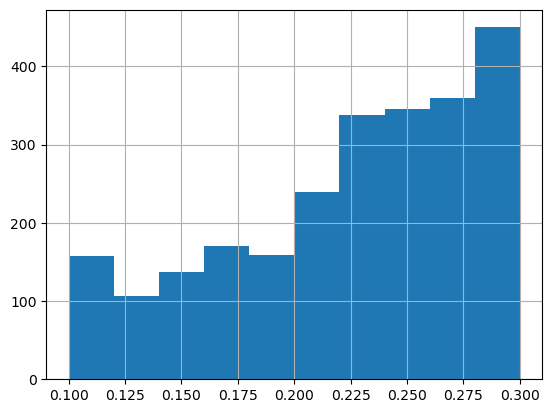

In [10]:
cut_samp_onxmm['Z_LAMBDA'].hist()

In [11]:
# cut_samp_onxmm.to_csv("desy3_richlt20_zlte06_onxmm.csv", index=False)

## What is the distribution of redMaPPer richnesses like?

<Axes: >

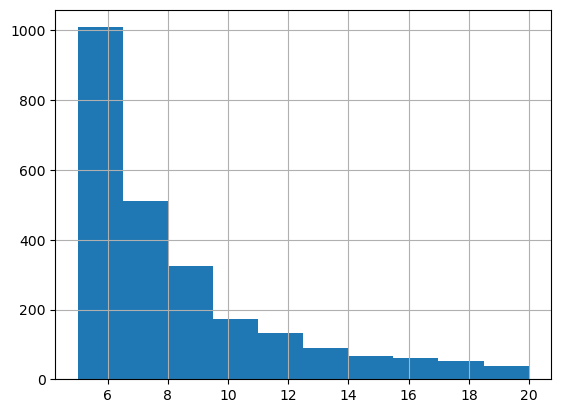

In [12]:
cut_samp_onxmm['LAMBDA_CHISQ'].hist()

In [13]:
xm.filtered_obs_ids.shape

(2423,)

## Setting up an Archive

### Final XMM filtering

### Defining the archive

In [14]:
stop

NameError: name 'stop' is not defined

In [ ]:
arch = Archive('lowz_richlte20_desy3rm', xm_sel)
arch.info()

## Processing the archive

In [ ]:
full_process_xmm(arch)

In [ ]:
arch